
# โหลดไฟล์ API Token จาก Kaggle

In [47]:
import os
os.environ["KAGGLE_API_TOKEN"] = "KGAT_9acc6ba84d7672afea5cecf0fb226318"

In [48]:
# โหลด Dataset ต้นทางของลิงก์นี้
!kaggle datasets download -d cooperunion/cardataset

# แตกไฟล์ zip
!unzip -o cardataset.zip

# เช็คชื่อไฟล์ที่ได้ (จะได้ไฟล์ data.csv)
!ls -lh data.csv

Dataset URL: https://www.kaggle.com/datasets/cooperunion/cardataset
License(s): unknown
cardataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  cardataset.zip
  inflating: data.csv                
-rw-r--r-- 1 root root 1.5M Sep 20  2019 data.csv


In [49]:
import pandas as pd
# อ่านข้อมูลเข้า DataFrame
df = pd.read_csv("data.csv")
print("Data Shape:", df.shape)


Data Shape: (11914, 16)


In [50]:
df.iloc[:]

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620
11912,Acura,ZDX,2013,premium unleaded (recommended),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50920


# ตรวจสอบโครงสร้างและ Missing Values

In [51]:
# ดูประเภทข้อมูลและค่า Missing
print("--- Data Info ---")
df.info()

print("\n--- Missing Values Count ---")
print(df.isnull().sum())

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: f

# Clean Data & Preprocessing

In [52]:
import pandas as pd
import numpy as np

# 1. ปรับชื่อคอลัมน์ให้อ่านง่าย: ตัวพิมพ์เล็กทั้งหมด และแทนที่ช่องว่างด้วย underscore '_'
df.columns = df.columns.str.lower().str.replace(' ', '_')

# 2. จัดการ Duplicate (แถวซ้ำ)
duplicates_count = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f"ลบแถวที่ซ้ำกันออกไป: {duplicates_count} แถว")

# 3. จัดการคอลัมน์ market_category ที่ค่าว่างเยอะ
df = df.drop(columns=['market_category'])

# 4. จัดการแถวที่มีค่า Missing Values ในคอลัมน์สเปกหลัก
# คอลัมน์ engine_hp, engine_cylinders, number_of_doors, engine_fuel_type มีค่าแหว่งนิดหน่อย

missing_before = df.isnull().sum().sum()
df = df.dropna(subset=['engine_hp', 'engine_cylinders', 'number_of_doors', 'engine_fuel_type']).reset_index(drop=True)
print(f"จัดการ Missing values เรียบร้อย (ลดไป {missing_before - df.isnull().sum().sum()} จุด)")

# 5. แปลงชนิดข้อมูล (Casting Data Types) ให้ถูกต้อง

df['number_of_doors'] = df['number_of_doors'].astype(int)
df['engine_cylinders'] = df['engine_cylinders'].astype(int)

# 6. Feature Engineering เบื้องต้น: แปลง 'year' เป็นอายุรถ 'car_age'
df['car_age'] = 2026 - df['year']
df = df.drop(columns=['year'])

# 7. กรอง Outliers เบื้องต้นที่ข้อมูลเพี้ยนชัดเจน (เช่น ราคา msrp <= 0)
df = df[df['msrp'] > 0].reset_index(drop=True)

print("\n--- สรุปผลหลังการ Clean ข้อมูล ---")
print("ขนาดข้อมูลหลัง Clean (Rows, Columns):", df.shape)
print("จำนวน Missing Values คงเหลือรวมทุกคอลัมน์:", df.isnull().sum().sum())
df.head(5)

ลบแถวที่ซ้ำกันออกไป: 715 แถว
จัดการ Missing values เรียบร้อย (ลดไป 108 จุด)

--- สรุปผลหลังการ Clean ข้อมูล ---
ขนาดข้อมูลหลัง Clean (Rows, Columns): (11097, 15)
จำนวน Missing Values คงเหลือรวมทุกคอลัมน์: 0


,make,model,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp,car_age
0,BMW,1 Series M,premium unleaded (required),335.0,6,MANUAL,rear wheel drive,2,Compact,Coupe,26,19,3916,46135,15
1,BMW,1 Series,premium unleaded (required),300.0,6,MANUAL,rear wheel drive,2,Compact,Convertible,28,19,3916,40650,15
2,BMW,1 Series,premium unleaded (required),300.0,6,MANUAL,rear wheel drive,2,Compact,Coupe,28,20,3916,36350,15
3,BMW,1 Series,premium unleaded (required),230.0,6,MANUAL,rear wheel drive,2,Compact,Coupe,28,18,3916,29450,15
4,BMW,1 Series,premium unleaded (required),230.0,6,MANUAL,rear wheel drive,2,Compact,Convertible,28,18,3916,34500,15


In [53]:
df.dtypes

,0
make,object
model,object
engine_fuel_type,object
engine_hp,float64
engine_cylinders,int64
transmission_type,object
driven_wheels,object
number_of_doors,int64
vehicle_size,object
vehicle_style,object


In [54]:
# 1. ทิ้งคอลัมน์ที่ไม่จำเป็น
drop_cols = ["model", "city_mpg", "popularity"]
df_selected = df.drop(columns=drop_cols).copy()

print(f"ลดจำนวนคอลัมน์จาก {df.shape[1]} เหลือ {df_selected.shape[1]} คอลัมน์")

# 2. ตรวจสอบรายชื่อฟีเจอร์ที่เหลืออยู่
print("\n--- Features ที่เก็บไว้ใช้เทรนโมเดล ---")
print(list(df_selected.columns))

# 3. กำหนดกลุ่มตัวเลขและกลุ่มหมวดหมู่อีกครั้ง
numeric_features = [
    "engine_hp",
    "engine_cylinders",
    "number_of_doors",
    "highway_mpg",
    "car_age",
]

categorical_features = [
    "make",
    "engine_fuel_type",
    "transmission_type",
    "driven_wheels",
    "vehicle_size",
    "vehicle_style",
]

print(f"\nNumeric features ({len(numeric_features)} ตัว): {numeric_features}")
print(
    f"Categorical features ({len(categorical_features)} ตัว): {categorical_features}"
)

ลดจำนวนคอลัมน์จาก 15 เหลือ 12 คอลัมน์

--- Features ที่เก็บไว้ใช้เทรนโมเดล ---
['make', 'engine_fuel_type', 'engine_hp', 'engine_cylinders', 'transmission_type', 'driven_wheels', 'number_of_doors', 'vehicle_size', 'vehicle_style', 'highway_mpg', 'msrp', 'car_age']

Numeric features (5 ตัว): ['engine_hp', 'engine_cylinders', 'number_of_doors', 'highway_mpg', 'car_age']
Categorical features (6 ตัว): ['make', 'engine_fuel_type', 'transmission_type', 'driven_wheels', 'vehicle_size', 'vehicle_style']


# Boxplot ดู Outliers ในคอลัมน์ตัวเลข

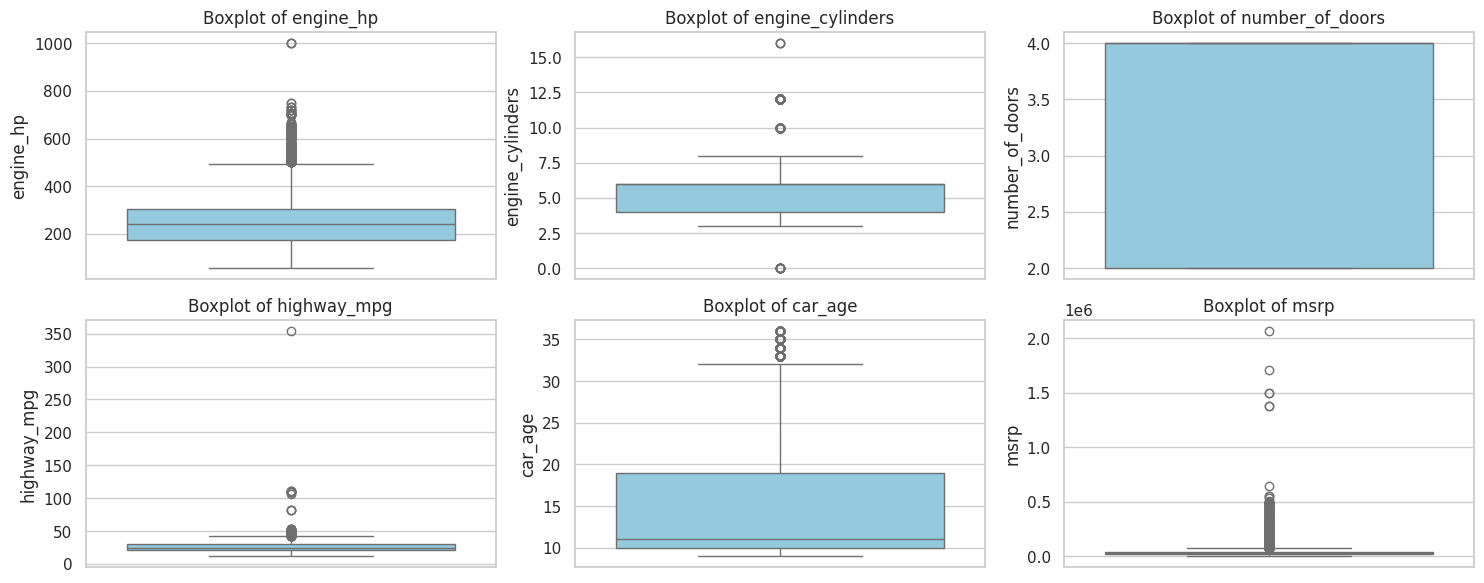

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))
for i, col in enumerate(numeric_features + ["msrp"], 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df_selected[col], color="skyblue")
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

# จัดการ Outliers ด้วยวิธี Domain Knowledge & Interquartile Range (IQR)

In [56]:
initial_rows = len(df_selected)

# 1. กรองตาม Domain Knowledge ที่ชัดเจน

df_clean = df_selected[
    (df_selected["msrp"] >= 2000)
    & (df_selected["msrp"] <= 200000)
    & (df_selected["highway_mpg"] <= 60)
    & (df_selected["engine_hp"] <= 750)
].copy()

# 2. ใช้ IQR ตัด Outliers เฉพาะคอลัมน์ highway_mpg และ engine_hp เพิ่มเติม
for col in ["highway_mpg", "engine_hp"]:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_clean = df_clean[
        (df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)
    ]

df_clean = df_clean.reset_index(drop=True)
dropped_rows = initial_rows - len(df_clean)

print(f"ตัด Outliers ออกไปทั้งหมด: {dropped_rows} แถว")
print(f"ข้อมูลคงเหลือสำหรับเทรน: {len(df_clean)} แถว (จากเดิม {initial_rows})")

ตัด Outliers ออกไปทั้งหมด: 688 แถว
ข้อมูลคงเหลือสำหรับเทรน: 10409 แถว (จากเดิม 11097)


# ตรวจสอบความสะอาดหลังตัด Outliers

In [57]:
# ดูการกระจายตัวของราคา (MSRP) อีกรอบ
print(df_clean[["engine_hp", "highway_mpg", "msrp"]].describe())

          engine_hp   highway_mpg           msrp
count  10409.000000  10409.000000   10409.000000
mean     238.513498     26.297339   32353.111154
std       84.924862      5.867817   21952.458076
min       55.000000     12.000000    2000.000000
25%      170.000000     22.000000   20995.000000
50%      227.000000     26.000000   29785.000000
75%      295.000000     30.000000   40685.000000
max      485.000000     42.000000  199054.000000


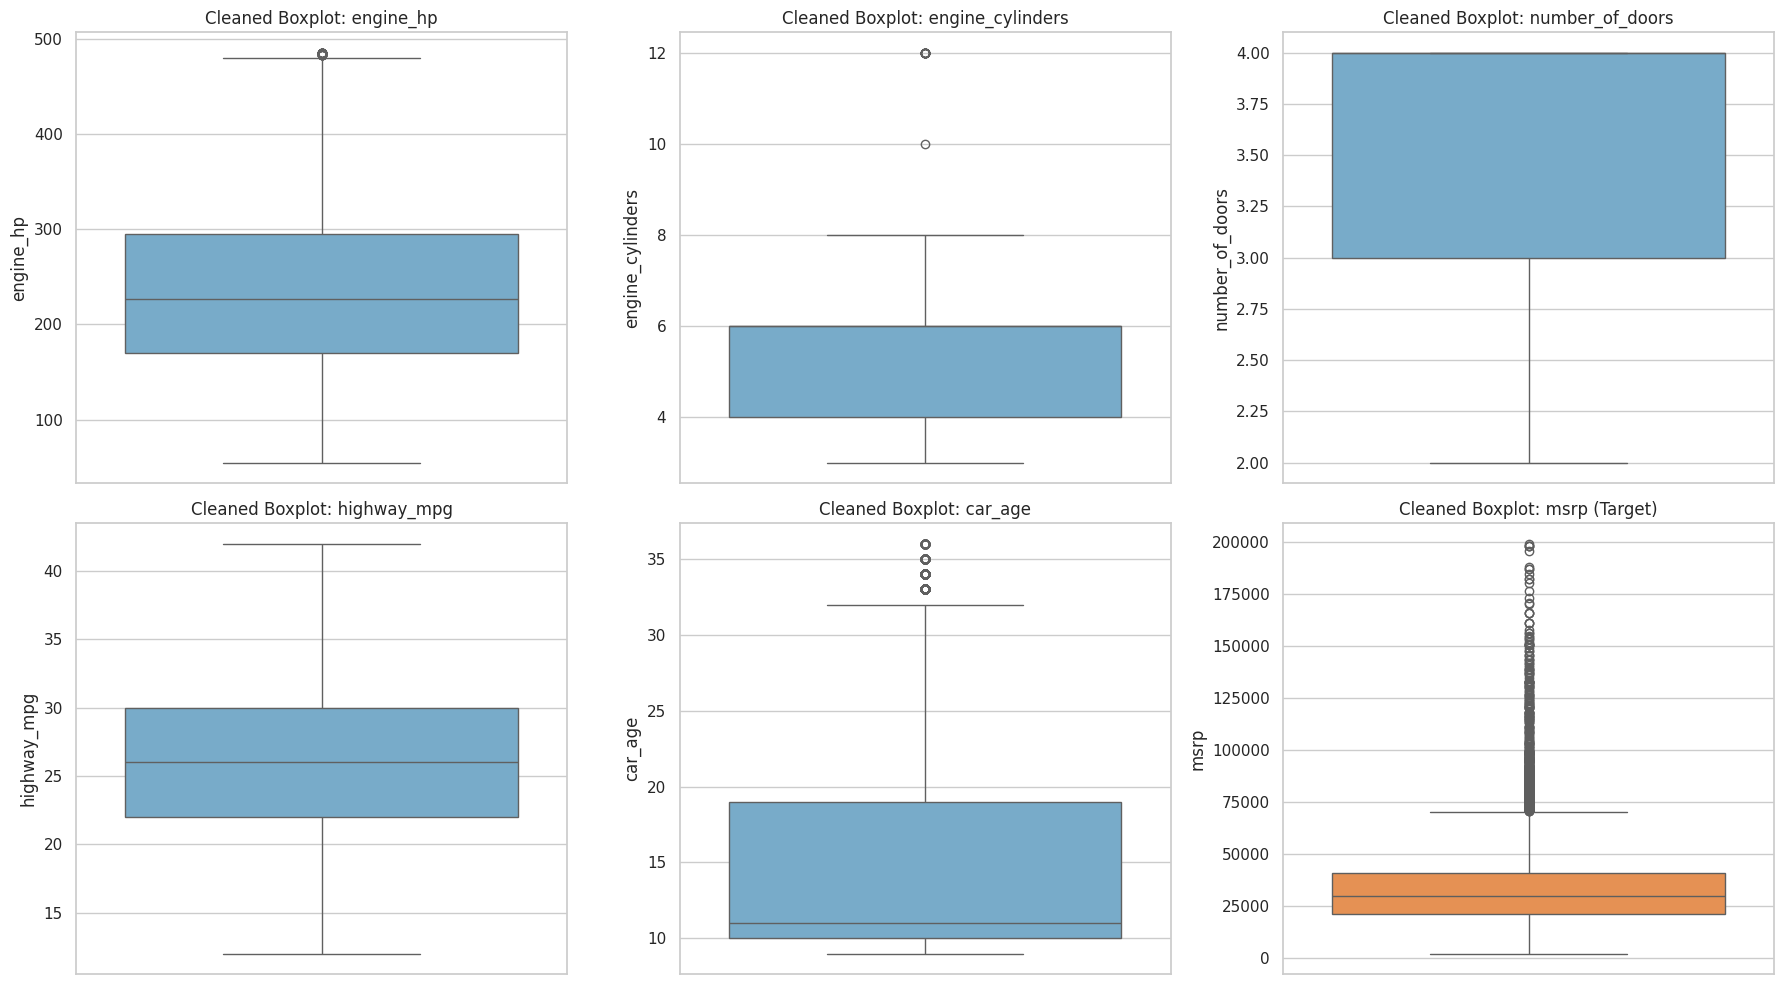

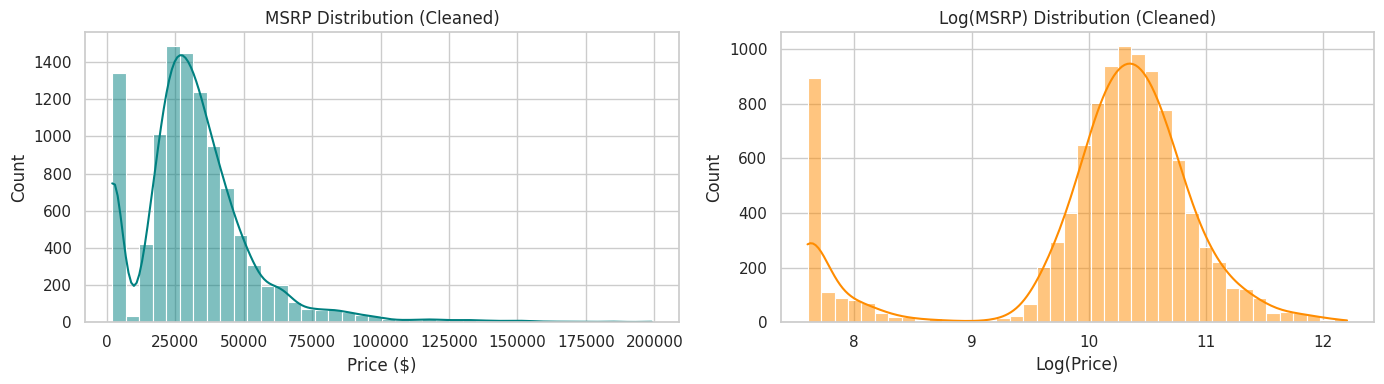

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Boxplot ดู Outliers ของ Features ตัวเลขหลังตัด
for idx, col in enumerate(numeric_features):
    row, col_idx = divmod(idx, 3)
    sns.boxplot(y=df_clean[col], ax=axes[row, col_idx], color="#6baed6")
    axes[row, col_idx].set_title(f"Cleaned Boxplot: {col}", fontsize=12)

# 2. Boxplot ของ Target (MSRP)
sns.boxplot(y=df_clean["msrp"], ax=axes[1, 2], color="#fd8d3c")
axes[1, 2].set_title("Cleaned Boxplot: msrp (Target)", fontsize=12)

plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# พล็อต Distribution ของ Target ทั้งแบบดิบและแบบ Log Transform
# -------------------------------------------------------------
plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
sns.histplot(df_clean["msrp"], kde=True, color="teal", bins=40)
plt.title("MSRP Distribution (Cleaned)")
plt.xlabel("Price ($)")

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df_clean["msrp"]), kde=True, color="darkorange", bins=40)
plt.title("Log(MSRP) Distribution (Cleaned)")
plt.xlabel("Log(Price)")

plt.tight_layout()
plt.show()

# Data Transformation

In [59]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 1. แยก Features (X) และ Target (y)
X = df_clean.drop(columns=['msrp'])
y = np.log1p(df_clean['msrp'])

# 2. นิยามกลุ่มฟีเจอร์
numeric_features = ['engine_hp', 'engine_cylinders', 'number_of_doors', 'highway_mpg', 'car_age']
categorical_features = ['make', 'engine_fuel_type', 'transmission_type', 'driven_wheels', 'vehicle_size', 'vehicle_style']

# 3. สร้าง Transformer Object
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

# 4. Fit & Transform ข้อมูล X
X_transformed = preprocessor.fit_transform(X)

# 5. ดึงชื่อคอลัมน์ใหม่ทั้งหมดหลังทำ One-Hot
num_cols = numeric_features
cat_cols = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()
all_features_transformed = num_cols + cat_cols

# 6. สร้าง DataFrame มาดูตัวอย่าง 5 แถวแรกหลังแปลงรูป
X_transformed_df = pd.DataFrame(X_transformed, columns=all_features_transformed)

print(f"ขนาด Features ก่อน Transform: {X.shape}")
print(f"ขนาด Features หลัง Transform: {X_transformed_df.shape}")
X_transformed_df.iloc[:5, :8]  # ดู 8 คอลัมน์แรกเพื่อเช็คสเกล

ขนาด Features ก่อน Transform: (10409, 11)
ขนาด Features หลัง Transform: (10409, 80)


,engine_hp,engine_cylinders,number_of_doors,highway_mpg,car_age,make_Acura,make_Alfa Romeo,make_Aston Martin
0,1.136194,0.341501,-1.734845,-0.050675,-0.067165,0.0,0.0,0.0
1,0.724045,0.341501,-1.734845,0.290183,-0.067165,0.0,0.0,0.0
2,0.724045,0.341501,-1.734845,0.290183,-0.067165,0.0,0.0,0.0
3,-0.100252,0.341501,-1.734845,0.290183,-0.067165,0.0,0.0,0.0
4,-0.100252,0.341501,-1.734845,0.290183,-0.067165,0.0,0.0,0.0


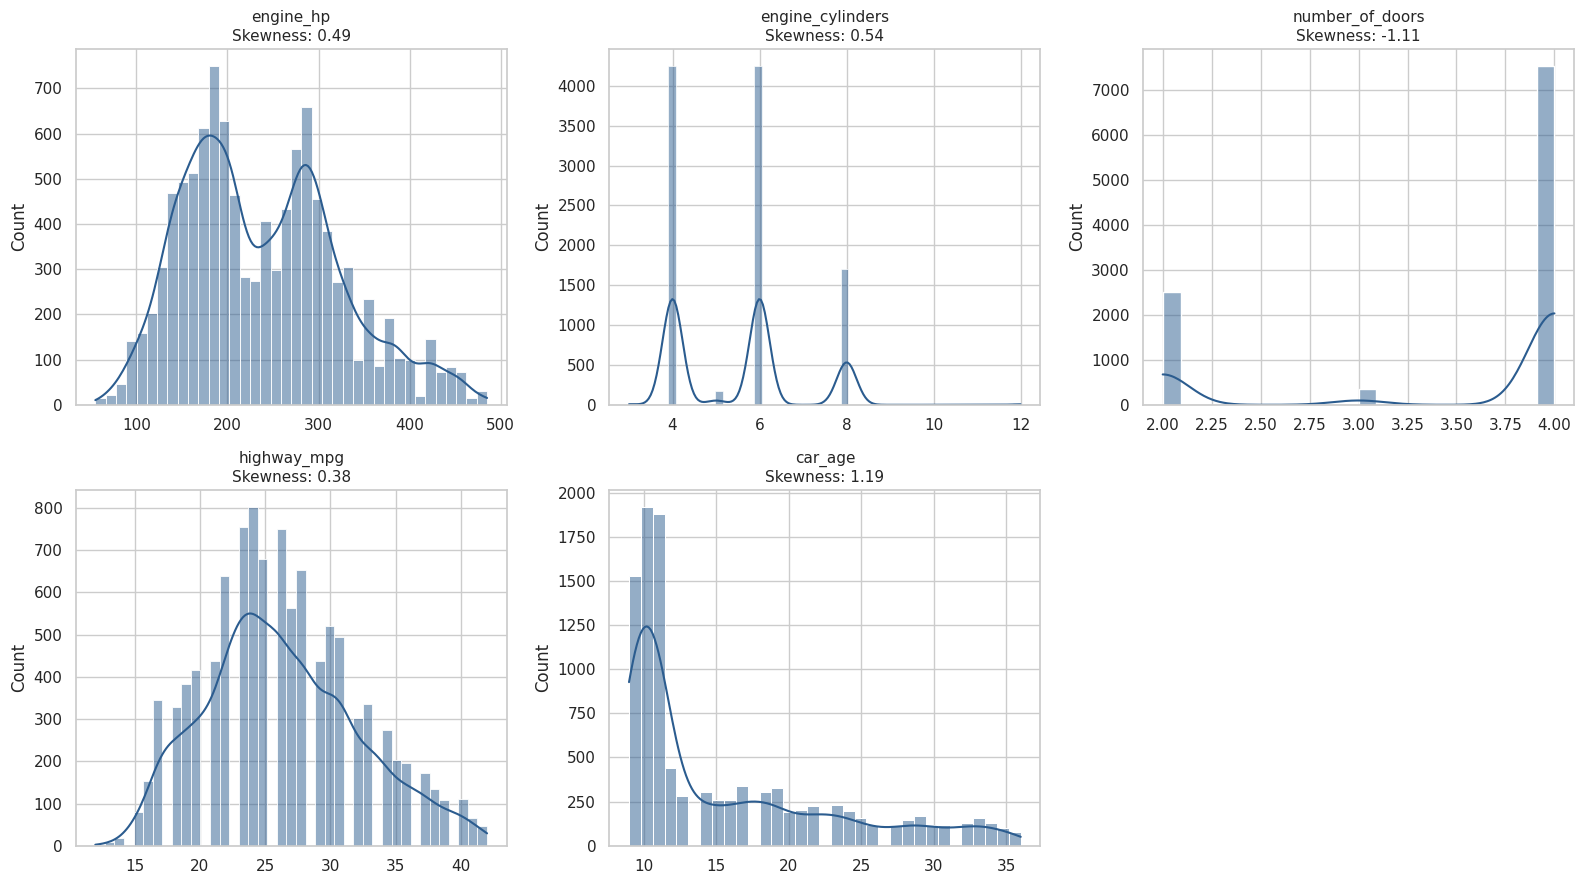

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for idx, col in enumerate(numeric_features):
    row, col_idx = divmod(idx, 3)
    skew_val = df_clean[col].skew()

    sns.histplot(df_clean[col], kde=True, ax=axes[row, col_idx], color="#2b5c8f")
    axes[row, col_idx].set_title(
        f"{col}\nSkewness: {skew_val:.2f}", fontsize=11
    )
    axes[row, col_idx].set_xlabel("")

# ช่องสุดท้ายว่างไว้ พล็อต Target ซ้ำเทียบความเข้าใจ
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

# ประเมินผลเปรียบเทียบ Linear Regression, Random Forest, และ **HistGradientBoosting**

In [62]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    HistGradientBoostingRegressor,
    RandomForestRegressor,
    VotingRegressor,
)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

# -------------------------------------------------------------
# 1. Feature Engineering: สร้างฟีเจอร์เพิ่มพลังทำนาย
# -------------------------------------------------------------
df_enhanced = df_clean.copy()

# 1.1 ความแรงเฉลี่ยต่อลูกสูบ
df_enhanced["hp_per_cylinder"] = (
    df_enhanced["engine_hp"] / df_enhanced["engine_cylinders"]
)

# 1.2 สัดส่วนปฏิสัมพันธ์ระหว่างอายุกับแรงม้า
df_enhanced["hp_age_ratio"] = df_enhanced["engine_hp"] / (
    df_enhanced["car_age"] + 1
)

# 1.3 แยก Segment แบรนด์หรู
luxury_brands = [
    "BMW",
    "Mercedes-Benz",
    "Audi",
    "Porsche",
    "Bentley",
    "Aston Martin",
    "Ferrari",
    "Lamborghini",
    "Maserati",
    "Land Rover",
    "Lexus",
    "Rolls-Royce",
]
df_enhanced["is_luxury"] = (
    df_enhanced["make"].isin(luxury_brands).astype(int)
)

# -------------------------------------------------------------
# 2. แยก Features (X) และ Target (y)
# -------------------------------------------------------------
X = df_enhanced.drop(columns=["msrp"])
y = np.log1p(df_enhanced["msrp"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------------------------------------
# 3. กำหนดกลุ่ม Features
# -------------------------------------------------------------
skewed_feature = ["car_age", "hp_age_ratio"]
normal_numeric_features = [
    "engine_hp",
    "engine_cylinders",
    "number_of_doors",
    "highway_mpg",
    "hp_per_cylinder",
    "is_luxury",
]
categorical_features = [
    "make",
    "engine_fuel_type",
    "transmission_type",
    "driven_wheels",
    "vehicle_size",
    "vehicle_style",
]

# -------------------------------------------------------------
# 4. สร้าง Preprocessor Pipeline
# -------------------------------------------------------------
skewed_pipe = Pipeline(
    [("log", FunctionTransformer(np.log1p)), ("scaler", StandardScaler())]
)

numeric_pipe = Pipeline([("scaler", StandardScaler())])

categorical_pipe = Pipeline(
    [("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("skew", skewed_pipe, skewed_feature),
        ("num", numeric_pipe, normal_numeric_features),
        ("cat", categorical_pipe, categorical_features),
    ]
)

# -------------------------------------------------------------
# 5. กำหนดโมเดลพร้อมจูน Hyperparameters
# -------------------------------------------------------------
# 5.1 Random Forest
tuned_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=25,
    min_samples_split=4,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
)

# 5.2 HistGradientBoosting
tuned_hgb = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=45,
    l2_regularization=2.0,
    random_state=42,
)

# 5.3 Voting Ensemble
ensemble_voting = VotingRegressor(
    estimators=[("rf", tuned_rf), ("hgb", tuned_hgb)], weights=[0.55, 0.45]
)

models = {
    "Linear Regression (Baseline)": LinearRegression(),
    "Random Forest (Tuned)": tuned_rf,
    "HistGradientBoosting (Tuned)": tuned_hgb,
    "Ensemble (RF + HGB)": ensemble_voting,
}

# -------------------------------------------------------------
# 6. วนลูปเทรนและประเมินผล
# -------------------------------------------------------------
results = []
trained_pipelines = {}

for name, model in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])

    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe

    # ทำนายผลและแปลงกลับเป็นสเกลดอลลาร์จริง ($)
    y_pred_log = pipe.predict(X_test)
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_test)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    results.append(
        {
            "Model": name,
            "MAE ($)": f"${mae:,.2f}",
            "RMSE ($)": f"${rmse:,.2f}",
            "R2 Score": round(r2, 4),
        }
    )

results_df = pd.DataFrame(results)
results_df

,Model,MAE ($),RMSE ($),R2 Score
0,Linear Regression (Baseline),"$9,188.46","$13,408.79",0.6584
1,Random Forest (Tuned),"$2,640.37","$5,151.27",0.9496
2,HistGradientBoosting (Tuned),"$2,664.47","$5,018.90",0.9521
3,Ensemble (RF + HGB),"$2,585.22","$4,943.71",0.9536


In [63]:
import joblib

best_ensemble = trained_pipelines['Ensemble (RF + HGB)']
joblib.dump(best_ensemble, 'car_price_ensemble_model.joblib')
print("บันทึกโมเดล Ensemble เรียบร้อยแล้ว!")

บันทึกโมเดล Ensemble เรียบร้อยแล้ว!
